Simple Two Hypothesis

In [1]:
import numpy as np

# prior probability for fair (H1) and biased (H2) coins
P_H1 = 0.5 # prior for H1 : coin is fair
P_H2 = 0.5 # prior for H2 : coin is biased (P(heads) = 0.7)

# likelihood of the data (coin flip result under each hypothesis)
def likelihood(data, hypothesis):
    if hypothesis == 'H1': # fair coin
        return 0.5 
    elif hypothesis == 'H2': # biased coin
        return 0.7 if data == 'H' else 0.3

# update beliefs using Bayes' theorem
def bayesian_update(prior_H1, prior_H2, data):
    #likelihood
    likelihood_H1 = likelihood(data, 'H1')
    likelihood_H2 = likelihood(data, 'H2')

    # total evidence P(D)
    P_data = likelihood_H1 * prior_H1 + likelihood_H2 * prior_H2

    # posterior for H1 (fair coin)
    posterior_H1 = (likelihood_H1 * prior_H1) / P_data
    # posterior for H2 (biased coin)
    posterior_H2 = (likelihood_H2 * prior_H2) / P_data

    return posterior_H1, posterior_H2

# simulate series of coin flips 
# coin flip = [''H', 'T', 'H', 'H', 'T'] # example sequence of coin flips
# generate 100 random coin flips (1 for heads, 0 for tails)
coin_flips = np.random.choice([1, 0], size=20) 

P_H1_Posterior = P_H1
P_H2_Posterior = P_H2

# perform Bayesian updates for each coin flip
for flip in coin_flips:
    P_H1_Posterior, P_H2_Posterior = bayesian_update(P_H1_Posterior, P_H2_Posterior,flip)
    print(f'After observing flip {flip}: P(H1|data) = {P_H1_Posterior:.4f}, P(H2|data) = {P_H2_Posterior:.4f}')

After observing flip 1: P(H1|data) = 0.6250, P(H2|data) = 0.3750
After observing flip 1: P(H1|data) = 0.7353, P(H2|data) = 0.2647
After observing flip 0: P(H1|data) = 0.8224, P(H2|data) = 0.1776
After observing flip 0: P(H1|data) = 0.8853, P(H2|data) = 0.1147
After observing flip 1: P(H1|data) = 0.9279, P(H2|data) = 0.0721
After observing flip 0: P(H1|data) = 0.9554, P(H2|data) = 0.0446
After observing flip 0: P(H1|data) = 0.9728, P(H2|data) = 0.0272
After observing flip 1: P(H1|data) = 0.9835, P(H2|data) = 0.0165
After observing flip 1: P(H1|data) = 0.9900, P(H2|data) = 0.0100
After observing flip 0: P(H1|data) = 0.9940, P(H2|data) = 0.0060
After observing flip 1: P(H1|data) = 0.9964, P(H2|data) = 0.0036
After observing flip 0: P(H1|data) = 0.9978, P(H2|data) = 0.0022
After observing flip 1: P(H1|data) = 0.9987, P(H2|data) = 0.0013
After observing flip 1: P(H1|data) = 0.9992, P(H2|data) = 0.0008
After observing flip 1: P(H1|data) = 0.9995, P(H2|data) = 0.0005
After observing flip 1: P

#### Beta distribution 
for binomial for likelihood then beta for prior

After observing 1 flip(s) (H) : posterior alpha = 2, beta = 1
After observing 2 flip(s) (T) : posterior alpha = 2, beta = 2
After observing 3 flip(s) (H) : posterior alpha = 3, beta = 2
After observing 4 flip(s) (H) : posterior alpha = 4, beta = 2
After observing 5 flip(s) (T) : posterior alpha = 4, beta = 3
After observing 6 flip(s) (H) : posterior alpha = 5, beta = 3
After observing 7 flip(s) (T) : posterior alpha = 5, beta = 4
After observing 8 flip(s) (T) : posterior alpha = 5, beta = 5


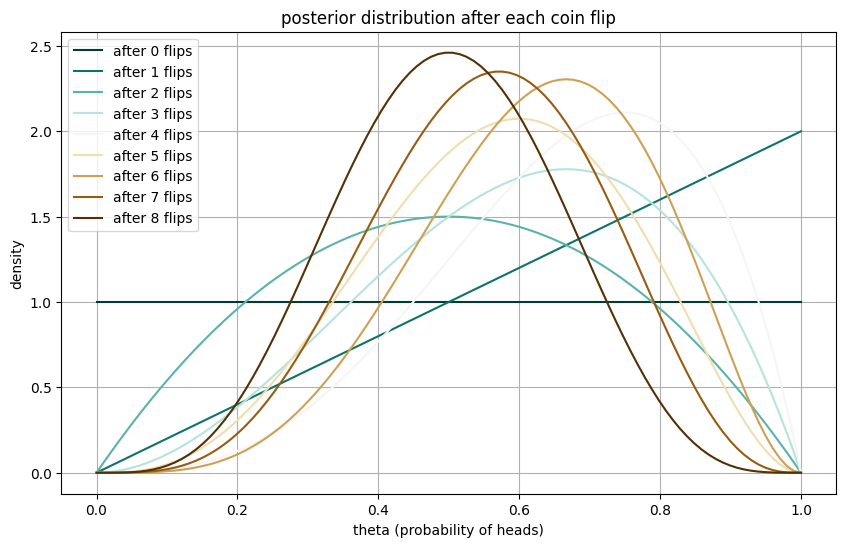

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta

# function to compute the likelihood of the data given theta 
def likelihood(theta,data):
    #binomial likelihood for the coin flips (Bernouli Trials)
    heads = np.sum(data=='H')
    tails = np.sum(data=='T')
    return (theta** heads) * ((1-theta) ** tails)

# function to compute the posterior distriibution using bayesian updating 
def bayesian_update(prior_alpha,prior_beta,data):
    # calculate the number of heads and tails in the data 
    heads = np.sum(data=='H')
    tails = np.sum(data=='T')

    #update the prior (beta distribution) parameters 
    posterior_alpha = prior_alpha + heads
    posterior_beta = prior_beta + tails

    return posterior_alpha,posterior_beta

# prior : uniform distribution (Beta(1,1))
prior_alpha = 1
prior_beta = 1

# simulate a sequence of coin flips (H for heads, T for tails)
coin_flips = np.array(['H','T','H','H','T','H','T','T'])

# store prior values for plotting 
alphas = [prior_alpha]
betas = [prior_beta]

# perform bayesian update after each flip
for i, flip in enumerate(coin_flips):
    # update the posterior with the new data (new flip)
    prior_alpha, prior_beta = bayesian_update(prior_alpha,prior_beta,np.array([flip]))

    # store the updated posterior parameters
    alphas.append(prior_alpha)
    betas.append(prior_beta)

    print(f"After observing {i+1} flip(s) ({flip}) : posterior alpha = {prior_alpha}, beta = {prior_beta}")

# plot the evolution of the posterior distributions
theta_range = np.linspace(0,1,100)

plt.figure(figsize=(10,6))

cmap = plt.get_cmap('BrBG_r')
colors = cmap(np.linspace(0,1,len(alphas)))

for i in range(len(alphas)):
    posterior_pdf = beta.pdf(theta_range,alphas[i],betas[i])
    plt.plot(theta_range,posterior_pdf,color=colors[i],label=f"after {i} flips")

plt.title('posterior distribution after each coin flip')
plt.xlabel('theta (probability of heads)')
plt.ylabel('density')

plt.legend()
plt.grid(True)
plt.show()